# Домашнее задание №2

Тема "Доверительные интервалы"

Общие положения:
- Макс кол-во баллов за ДЗ - 25 баллов
- Качество оформления и кода играет роль

Список заданий:
1.



In [4]:
import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import math

plt.style.use('ggplot')
%matplotlib inline

In [ ]:
# задаём стандартное нормальное распределение
norm_distr = stats.norm(loc=0, scale=1)

# рассчитываем квантиль по заданному уровню значимости
alpha = 0.05
z = norm_distr.ppf(alpha/2)
print(z)

-1.9599639845400545


In [ ]:
def confidence_interval(z, s_mu, sigma, n):
    return s_mu - z * (sigma / np.sqrt(n)), s_mu + z * (sigma / np.sqrt(n))

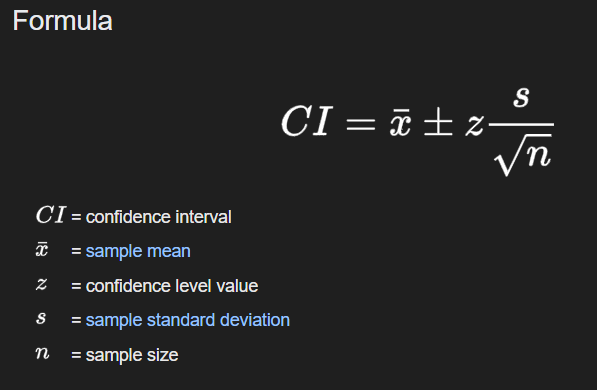

## Задание 1  
Компания утверждает, что длина шнурков в партии обуви имеет среднее значение 120 см, и стандартное отклонение в партии точно известно и составляет 5 см. Из выборки 25 шнурков было получено среднее значение длины 122 см. Найдите 99%-ый доверительный интервал для среднего значения длины шнурков (1 балл)

In [ ]:
mu = 120
sigma = 5
n = 25
s_mu = 122
alpha = 1 - 0.99
z = norm_distr.ppf(1 - alpha/2)

print(f"z: {z}")
print(f"Доверительный интервал: {confidence_interval(z, s_mu, sigma, n)} см")


Z: 2.5758293035489004
Доверительный интервал: (119.4241706964511, 124.5758293035489) см


##Задание 2
Компания исследует среднее время выполнения заказа курьерской службой. Было случайным образом выбрано 10 заказов, для которых среднее время доставки составило 45 минут, а выборочная дисперсия — 9 минут. Постройте 95%-ый доверительный интервал для среднего времени доставки заказа (1 балл)

In [ ]:
import numpy as np
from scipy.stats import t

n = 10
s_mu = 45
s = np.sqrt(9)
alpha = 1 - 0.95

df = n - 1 # степени свободы

t_critical = t.ppf(1 - alpha/2, df)

confidence_interval = (
    s_mu - t_critical * (s / np.sqrt(n)),
    s_mu + t_critical * (s / np.sqrt(n))
)


print(f"Доверительный интервал: {confidence_interval}")

Доверительный интервал: (42.85392928203498, 47.14607071796502)


## Задание 3
Интернет-магазин хочет определить долю пользователей, которые возвращаются для повторной покупки в течение месяца после первой покупки. Для этого он проанализировал выборку из 800 клиентов, и оказалось, что 240 из них сделали повторную покупку в течение месяца. Необходимо определить 95% доверительный интервал для истинной доли клиентов, которые возвращаются для повторной покупки в течение этого времени (1 балл)


In [ ]:
n_gen = 800
n_sample = 240
alpha = 1 - 0.95

z = norm_distr.ppf(1 - alpha/2)
p_hat = n_sample / n_gen

confidence_interval = (
    p_hat - z * np.sqrt((p_hat*(1 - p_hat))/n_gen),
    p_hat + z * np.sqrt((p_hat*(1 - p_hat))/n_gen)
    )

print(f"Доверительный интервал: {confidence_interval}")

Доверительный интервал: (0.2682449540949441, 0.3317550459050559)


## Задание 4
Два студента Тимофей и Пётр решают задачи из учебника по статистике, каждый со своей усердностью λ (количество решенных задач в день).
Тимофей считает себя более усердным студентом. Необходимо построить доверительный для разности λ1 - λ2 и проверить, правда ли это.
Студенты решают задачи независимо друг от друга (1 балл)

In [ ]:
a = [7, 5, 2, 8, 4, 9, 2, 6, 6, 7] # Тимофей
b = [3, 3, 3, 9, 9, 2, 2, 2, 2, 9] # Пётр

import numpy as np
from scipy.stats import t

# Выборочные средние
mean_a = np.mean(a)
mean_b = np.mean(b)
print(f"Средние для выборки A : {mean_a}")
print(f"Средние для выборки B : {mean_b}\n")

# Выборочные стандартные отклонения
std_a = np.std(a, ddof=1)
std_b = np.std(b, ddof=1)
print(f"Стандартное отклонения для выборки A : {std_a}")
print(f"Стандартное отклонения для выборки B : {std_b}\n")

# Размеры выборок
n_a = len(a)
n_b = len(b)

# Разность средних
mean_diff = mean_a - mean_b

alpha = 0.05
df = n_a + n_b - 2
t_critical = t.ppf(1 - alpha/2, df) # беру t, поскольку маленькая выборка и не уверен, что распределение нормальное

# Стандартная ошибка разности средних
std_error = np.sqrt((std_a ** 2) / n_a + (std_b ** 2) / n_b) # расчет для разности

confidence_interval = (
    mean_diff - t_critical * std_error,
    mean_diff + t_critical * std_error
)

print(f"Разность средних: {mean_diff}")
print(f"95%-ый доверительный интервал: {confidence_interval}")


Средние для выборки A : 5.6
Средние для выборки B : 4.4

Стандартное отклонения для выборки A : 2.3664319132398464
Стандартное отклонения для выборки B : 3.204163957519444

Разность средних: 1.1999999999999993
95%-ый доверительный интервал: (-1.4463835370337854, 3.846383537033784)


Тимофей считает себя более усердным студентом, однако на основе этой выборки мы не можем сделать вывод, что он действительно решает больше задач, чем Пётр, с уровнем уверенности 95%, поскольку доверительный интервал колеблиться между нулем. Иначе говоря, Тимофей может решить в день задача меньше или больше чем Пётр

## Задания 5-8 (5 баллов всего)

In [ ]:
!curl -O https://raw.githubusercontent.com/practical-jupyter/sample-data/refs/heads/master/anime/anime.csv >> anime.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  778k  100  778k    0     0  2459k      0 --:--:-- --:--:-- --:--:-- 2464k


Описание датафрейма:
- `anime_id` - ID
- `name` - название
- `genre` - жанр (строка с пречисление через запятую)
- `type` - формат
- `episodes` - кол-во эпизодов
- `rating` - средний рейтинг
- `members` - кол-во смотрящих

In [ ]:
df_anime = pd.read_csv('anime.csv')
df_anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10486 entries, 0 to 10485
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  10486 non-null  int64  
 1   name      10486 non-null  object 
 2   genre     10424 non-null  object 
 3   type      10463 non-null  object 
 4   episodes  10486 non-null  object 
 5   rating    10275 non-null  float64
 6   members   10486 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 573.6+ KB


## 5. Постройте доверительный интервал для среднего рейтинга по всем аниме (1 балл)

In [ ]:
rating_mean = df_anime['rating'].mean()
rating_std = df_anime['rating'].std()

alpha = 1 - 0.95
z = norm_distr.ppf(1 - alpha/2)

confidence_interval = (
    rating_mean - z * (rating_std / np.sqrt(len(df_anime))),
    rating_mean + z * (rating_std / np.sqrt(len(df_anime)))
)

print(f"Mean: {rating_mean}, std: {rating_std}")
print(f"Доверительный интервал: {confidence_interval}")

Mean: 6.493898783454988, std: 1.0665507971740387
Доверительный интервал: (6.47348494333964, 6.514312623570335)


\## 6. Постройте доверительные интервалы для средних рейтингов по жанрам  (1 балл)

In [ ]:
import numpy as np
from scipy.stats import norm

df_exploded_genre = df_anime.copy()
df_exploded_genre['exploded_genre'] = df_exploded_genre['genre'].str.split(", ")
df_exploded_genre = df_exploded_genre.explode('exploded_genre')

alpha = 1 - 0.95
z_critical = norm.ppf(1 - alpha / 2)

def calculate_confidence_interval(data):
    mean_rating = data.mean()
    std_rating = data.std()
    n = len(data)
    se = std_rating / np.sqrt(n)
    lower_bound = mean_rating - z_critical * se
    upper_bound = mean_rating + z_critical * se
    return mean_rating, lower_bound, upper_bound

genre_confidence_intervals = df_exploded_genre.groupby('exploded_genre')['rating'].apply(calculate_confidence_interval)

genre_confidence_intervals = genre_confidence_intervals.apply(pd.Series)
genre_confidence_intervals.columns = ['mean', 'lower_bound', 'upper_bound']

genre_confidence_intervals


,mean,lower_bound,upper_bound
exploded_genre,,,
Action,6.808614,6.772330,6.844897
Adventure,6.747665,6.711475,6.783855
Cars,6.468611,6.196229,6.740994
Comedy,6.622348,6.591134,6.653562
Dementia,4.991617,4.843913,5.139321
Demons,6.745760,6.605868,6.885653
Drama,6.994149,6.954450,7.033849
Fantasy,6.675725,6.636765,6.714685
Game,6.812275,6.688858,6.935693


## 7. Постройте доверительные интервалы среднего рейтинга по типам аниме (1 балл)

In [ ]:
import numpy as np
from scipy.stats import norm

alpha = 1 - 0.95
z_critical = norm.ppf(1 - alpha / 2)

def calculate_confidence_interval(data):
    mean_rating = data.mean()
    std_rating = data.std()
    n = len(data)
    se = std_rating / np.sqrt(n)
    lower_bound = mean_rating - z_critical * se
    upper_bound = mean_rating + z_critical * se
    return mean_rating, lower_bound, upper_bound

type_confidence_intervals = df_anime.groupby('type')['rating'].apply(calculate_confidence_interval)

type_confidence_intervals = type_confidence_intervals.apply(pd.Series)
type_confidence_intervals.columns = ['mean', 'lower_bound', 'upper_bound']

type_confidence_intervals


,mean,lower_bound,upper_bound
type,,,
Movie,6.311996,6.262490,6.361503
Music,5.584259,5.499177,5.669342
ONA,5.633297,5.545879,5.720714
OVA,6.474058,6.433024,6.515092
Special,6.523434,6.477614,6.569254
TV,6.900149,6.871179,6.929118


## 8. По доверительным интервалам для episodes, rating и members оцените количество аномалий (2 балла)

In [ ]:
"""
NOTE: Здесь я использовал t-статистику для эксперимента
"""


import numpy as np
from scipy.stats import t
import pandas as pd

alpha = 1 - 0.95

df_anime.loc[:, 'episodes'] = pd.to_numeric(df_anime['episodes'], errors='coerce')

def calculate_anomalies(data, column_name):
    mean_value = data[column_name].mean()
    std_value = data[column_name].std()
    n = len(data[column_name].dropna())

    t_critical = t.ppf(1 - alpha / 2, df=n - 1)

    se = std_value / np.sqrt(n)

    lower_bound = mean_value - t_critical * se
    upper_bound = mean_value + t_critical * se

    outliers = data[(data[column_name] < lower_bound) | (data[column_name] > upper_bound)]

    return n, len(outliers), lower_bound, upper_bound

episodes_n, episodes_outliers, episodes_lower, episodes_upper = calculate_anomalies(df_anime, 'episodes')
rating_n, rating_outliers, rating_lower, rating_upper = calculate_anomalies(df_anime, 'rating')
members_n, members_outliers, members_lower, members_upper = calculate_anomalies(df_anime, 'members')

print(f"Episodes - выбросов: {np.round(episodes_outliers / episodes_n * 100, 3)}%, Доверительный интервал: ({episodes_lower}, {episodes_upper})")
print(f"Rating - выбросов: {np.round(rating_outliers / rating_n * 100, 3)}%, Доверительный интервал: ({rating_lower}, {rating_upper})")
print(f"Members - выбросов: {np.round(members_outliers / members_n * 100, 3)}%, Доверительный интервал: ({members_lower}, {members_upper})")


Episodes - выбросов: 94.478%, Доверительный интервал: (12.824527795848386, 14.786692290459971)
Rating - выбросов: 98.151%, Доверительный интервал: (6.473273976757219, 6.5145235901527565)
Members - выбросов: 98.951%, Доверительный интервал: (17396.251532555976, 19561.600079116728)


## Задания 9-15. Продуктовые метрики (16 баллов всего)

In [2]:
!curl -O https://raw.githubusercontent.com/alina-zhu/datasets/refs/heads/master/customer_shopping_data.csv >> customer_shopping_data.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 6410k  100 6410k    0     0  10.9M      0 --:--:-- --:--:-- --:--:-- 10.9M


Описание датафрейма:
- `invoice_no` - номер чека
- `customer_id` - id клиента
- `gender` - пол клиента
- `age` - возраст клиента
- `category` - категория товара
- `quantity` - количество единиц товаров в чеке
- `price` - цена товара
- `payment_method` - метод оплаты
- `invoice_date` - дата покупки


In [5]:
df = pd.read_csv('customer_shopping_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 6.8+ MB


In [ ]:
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date
0,I138884,upeszhn26j,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05
1,I317333,nyyoavbmge,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12
2,I127801,iksbmqrtj0,Male,20,Clothing,1,300.08,Cash,2021-11-09
3,I173702,zfhc107gzu,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16
4,I337046,diwrquryyt,Female,53,Books,4,60.60,Cash,2021-10-24


## 9. Посчитайте доверительный интервал для среднего возраста покупателей (1 балл)

In [ ]:
from scipy.stats import t

mean_age = df['age'].mean()
std_age = df['age'].std()

alpha = 1 - 0.95
t_statistic = t.ppf(1 - alpha/2, df=len(df)-1)

confidence_interval = (
    mean_age - t_statistic * (std_age / np.sqrt(len(df))),
    mean_age + t_statistic * (std_age / np.sqrt(len(df)))
)

print(f"Mean: {mean_age}, std: {std_age}")
print(f"Доверительный интервал: {confidence_interval}")

Mean: 43.42708909377922, std: 14.990053791852299
Доверительный интервал: (43.33392707517726, 43.52025111238119)


## 10. Посчитайте доверительные интервалы для среднего чека в каждой категории (1 балл)

In [ ]:
df_category_conf_int = pd.DataFrame()

for category in df['category'].unique():
    category_df = df[df['category'] == category]
    mean_price = category_df['price'].mean()
    std_price = category_df['price'].std()
    n = len(category_df)
    alpha = 1 - 0.95
    t_statistic = t.ppf(1 - alpha/2, df=n-1)
    confidence_interval = (
        mean_price - t_statistic * (std_price / np.sqrt(n)),
        mean_price + t_statistic * (std_price / np.sqrt(n))
    )

    df_category_conf_int.loc[category, 'mean_price'] = mean_price
    df_category_conf_int.loc[category, 'lower_bound'] = confidence_interval[0]
    df_category_conf_int.loc[category, 'upper_bound'] = confidence_interval[1]

df_category_conf_int

,mean_price,lower_bound,upper_bound
Clothing,901.084021,896.606553,905.561489
Shoes,1807.388568,1790.850685,1823.926450
Books,45.568621,44.971605,46.165636
Cosmetics,122.448626,121.532007,123.365244
Food & Beverage,15.671948,15.552264,15.791633
Toys,107.733185,106.750201,108.716170
Technology,3156.935548,3115.843167,3198.027930
Souvenir,34.894345,34.435052,35.353638


## 11. Посчитайте доверительные интервалы для среднего чека для каждого типа оплаты (1 балл)

In [ ]:
df_payment_method_conf_int = pd.DataFrame()

for category in df['payment_method'].unique():
    category_df = df[df['payment_method'] == category]
    mean_price = category_df['price'].mean()
    std_price = category_df['price'].std()
    n = len(category_df)
    alpha = 1 - 0.95
    t_statistic = t.ppf(1 - alpha/2, df=n-1)
    confidence_interval = (
        mean_price - t_statistic * (std_price / np.sqrt(n)),
        mean_price + t_statistic * (std_price / np.sqrt(n))
    )

    df_payment_method_conf_int.loc[category, 'mean_price'] = mean_price
    df_payment_method_conf_int.loc[category, 'lower_bound'] = confidence_interval[0]
    df_payment_method_conf_int.loc[category, 'upper_bound'] = confidence_interval[1]

df_payment_method_conf_int

,mean_price,lower_bound,upper_bound
Credit Card,688.542467,678.652374,698.432561
Debit Card,687.029135,674.098586,699.959684
Cash,690.823475,682.060207,699.586742


## 12. Посчитайте доверительный интервал для среднего количества позиций в чеке (1 балл)

In [ ]:
import numpy as np
from scipy.stats import t

positions_per_invoice = df.groupby('invoice_no')['quantity'].sum() # Хоть и инвойсы уникальны, все равно сделаю группировку для генерелизации задачи - на решение никак не влияет :)

mean_quantity = positions_per_invoice.mean()
std_quantity = positions_per_invoice.std()

alpha = 1 - 0.95
t_statistic = t.ppf(1 - alpha/2, df=len(positions_per_invoice) - 1)

confidence_interval = (
    mean_quantity - t_statistic * (std_quantity / np.sqrt(len(positions_per_invoice))),
    mean_quantity + t_statistic * (std_quantity / np.sqrt(len(positions_per_invoice)))
)

print(f"Mean quantity: {mean_quantity}, std: {std_quantity}")
print(f"Доверительный интервал: {confidence_interval}")


Mean quantity: 3.003428617392441, std: 1.4130251343053246
Доверительный интервал: (2.9946467760678455, 3.012210458717037)


## 13. Посчитайте доверительный для среднего количества покупателей в день (1 балл)

In [ ]:

df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['date'] = df['invoice_date'].dt.date

daily_customers = df.groupby('date')['customer_id'].nunique()

mean_daily_customers = daily_customers.mean()
std_daily_customers = daily_customers.std()

alpha = 1 - 0.95
t_statistic = t.ppf(1 - alpha / 2, df=len(daily_customers) - 1)

confidence_interval = (
    mean_daily_customers - t_statistic * (std_daily_customers / np.sqrt(len(daily_customers))),
    mean_daily_customers + t_statistic * (std_daily_customers / np.sqrt(len(daily_customers)))
)

print(f"Среднее количество покупателей в день: {mean_daily_customers}")
print(f"Доверительный интервал: {confidence_interval}")

Среднее количество покупателей в день: 124.67001254705144
Доверительный интервал: (123.91153976539648, 125.4284853287064)




## 14. Посчитайте помесячный retention для пользователей и доверительные интервалы для него (6 баллов)
Day N Retention = (Users Day N / Users Day 0) * 100

1) Постройте график retention   
2) Добавьте на график область доверительного интервала для каждого месяца

In [5]:
"""
1. Делим пользователей на кохорты - иначе первый месяц покупки (инвойса)
"""
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['cohort'] = df.groupby('customer_id')['invoice_date'].transform('min').dt.to_period('m')

"""
2. Допустим у нас есть некая когорта C, для этой когорты C я хочу знать сколько
активных пользователей N в каждый следующий месяц M. Эту метрику нужно просчитать
для каждой когорты. На выходе получиться:
- каждая когорта (cohort) имеет M месяцев (period) и каждый месяц имеет N пользователей
(active_users)
"""
cohort_data_list = []
# Проходим по каждой когорте
for cohort, group in df.groupby('cohort'):
    # Проходим по каждой дате инвойса внутри когорты
    for period, invoice_group in group.groupby(df['invoice_date'].dt.to_period('M')):
        # Подсчитываем уникальных пользователей для данной когорты и периода
        active_users = invoice_group['customer_id'].nunique()

        # Добавляем данные в список
        cohort_data_list.append({'cohort': cohort, 'period': period, 'active_users': active_users})

cohort_data = pd.DataFrame(cohort_data_list)
cohort_data


<ipython-input-5-c9729df2db43>:5: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'M' instead.
  df['cohort'] = df.groupby('customer_id')['invoice_date'].transform('min').dt.to_period('m')


,cohort,period,active_users
0,2021-01,2021-01,3706
1,2021-01,2021-02,199
2,2021-01,2021-03,245
3,2021-01,2021-04,233
4,2021-01,2021-05,251
...,...,...,...
373,2023-01,2023-02,51
374,2023-01,2023-03,11
375,2023-02,2023-02,693
376,2023-02,2023-03,15


In [6]:
"""
3. Мы посчитали количество уникальных пользователй для каждого периода
для каждой когорты. Чтобы расчитать retention - нужен знать, сколько
было пользователей в первом месяце каждой когорты
"""
initial_users = []
for cohort, group in df.groupby('cohort'):
    for period, invoice_group in group.groupby(df['invoice_date'].dt.to_period('M')):
        if period == cohort:
            initial_users.append(
                {
                    "cohort": cohort,
                    "initial_users": invoice_group['customer_id'].nunique()
                }
            )

initial_users = pd.DataFrame(initial_users)
initial_users.head()

,cohort,initial_users
0,2021-01,3706
1,2021-02,3116
2,2021-03,3242
3,2021-04,2953
4,2021-05,2874


In [7]:
"""
4. И так, на этот момент мы посчитали количество пользователей в каждый период
для каждой когорты. Также мы знаем, сколько пользователей было в начале когорты.
Теперь нужно найти ratio - (кол-во пользователей в данный период / кол-во пользователей
в начале когорты)

Это число от 0 до 1 будет говорить о retention пользователей.
"""
cohort_data = cohort_data.merge(initial_users, on='cohort')
cohort_data['retention'] = cohort_data['active_users'] / cohort_data['initial_users']
cohort_data

,cohort,period,active_users,initial_users,retention
0,2021-01,2021-01,3706,3706,1.000000
1,2021-01,2021-02,199,3706,0.053697
2,2021-01,2021-03,245,3706,0.066109
3,2021-01,2021-04,233,3706,0.062871
4,2021-01,2021-05,251,3706,0.067728
...,...,...,...,...,...
373,2023-01,2023-02,51,813,0.062731
374,2023-01,2023-03,11,813,0.013530
375,2023-02,2023-02,693,693,1.000000
376,2023-02,2023-03,15,693,0.021645


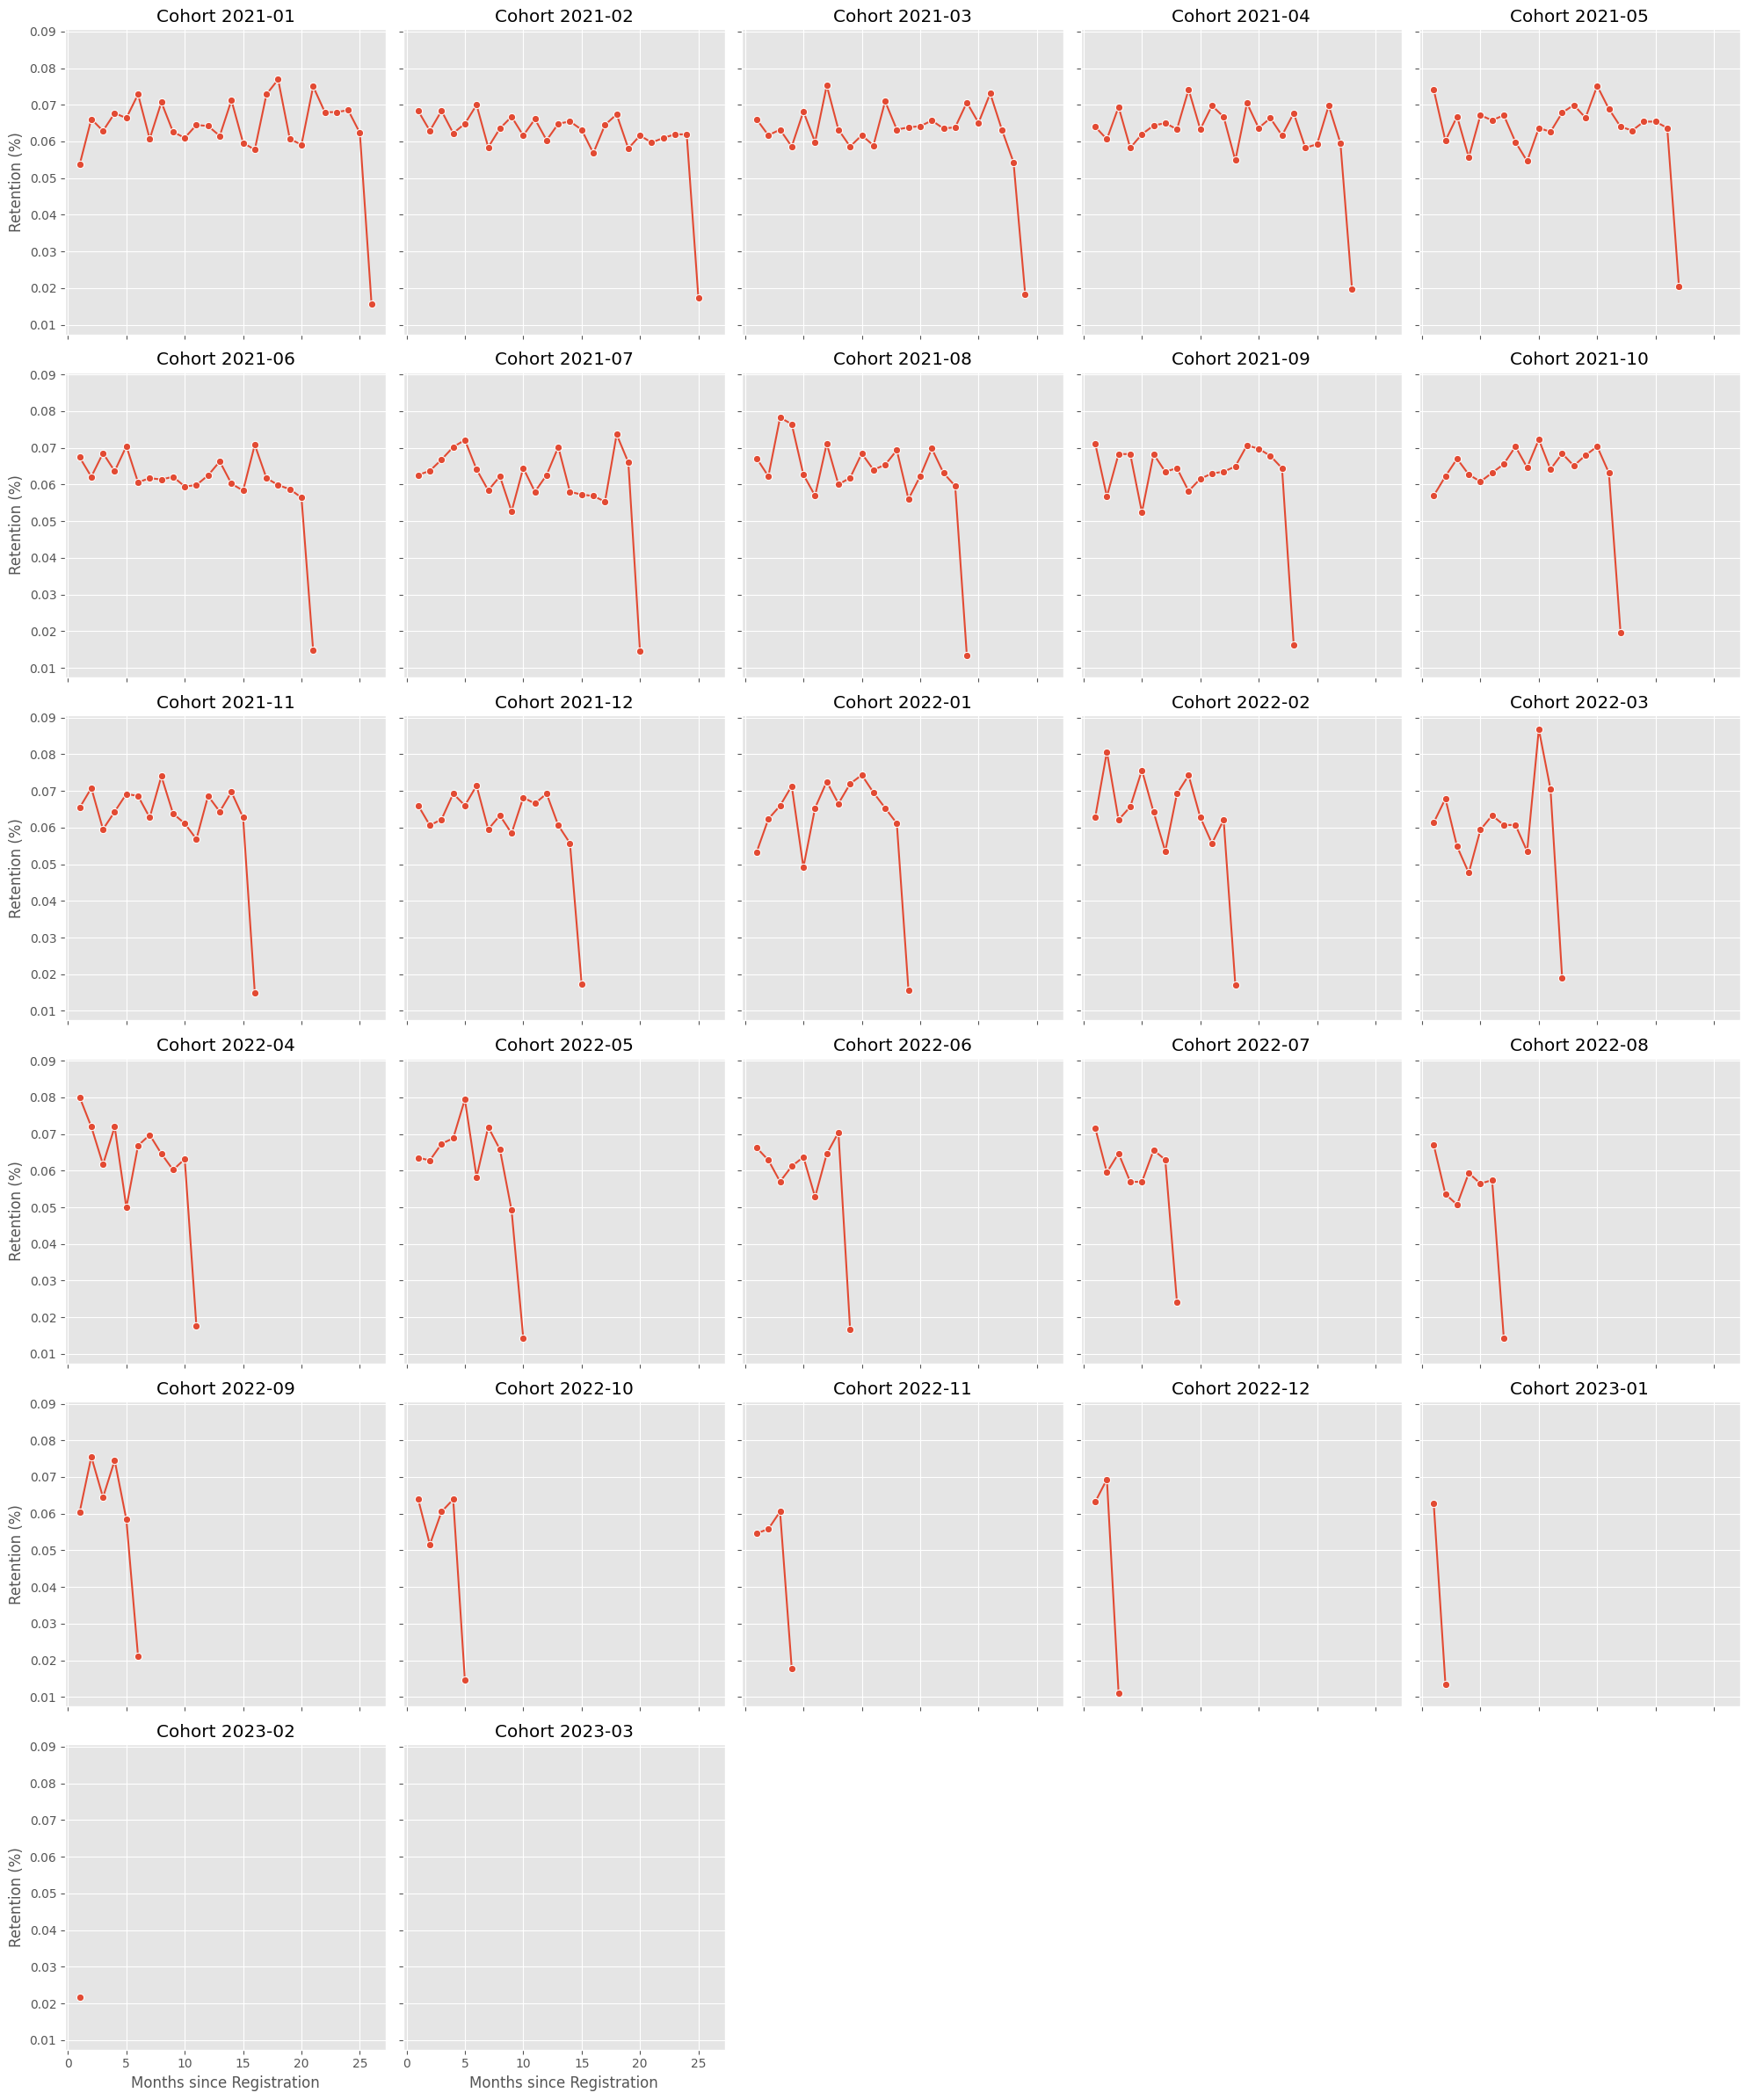

In [8]:
# Рассчитываем количество месяцев, прошедших с момента регистрации
cohort_data['month_since_registration'] = (cohort_data['period'] - cohort_data['cohort']).apply(lambda x: x.n)

# Определяем количество когорт и число графиков на строку
unique_cohorts = cohort_data['cohort'].unique()
cohorts_per_row = 5
n_rows = math.ceil(len(unique_cohorts) / cohorts_per_row)

# Создаем фигуру и сабплоты
fig, axes = plt.subplots(n_rows, cohorts_per_row, figsize=(20, 4 * n_rows), sharex=True, sharey=True)

# Проверяем, если только одна строка, чтобы избежать ошибки при итерации по axes
if n_rows == 1:
    axes = [axes]

# Плоский список осей для итерации
axes = axes.flatten()

# Построение графиков для каждой когорты
for idx, cohort in enumerate(unique_cohorts):
    # Данные для текущей когорты, исключая значения с retention 100%
    cohort_retention = cohort_data[
        (cohort_data['cohort'] == cohort) &
        (cohort_data['retention'] < 1.0)  # Убираем retention = 100%
    ]

    # Построение линии для текущей когорты
    sns.lineplot(
        data=cohort_retention,
        x='month_since_registration',
        y='retention',
        marker='o',
        ax=axes[idx]
    )

    # Настройка текущего сабплота
    axes[idx].set_title(f'Cohort {cohort}')
    axes[idx].set_xlabel('Months since Registration')
    axes[idx].set_ylabel('Retention (%)')
    axes[idx].grid(True)

# Убираем пустые сабплоты, если когорт меньше, чем количество графиков
for ax in axes[len(unique_cohorts):]:
    ax.set_visible(False)

# Настройка общего пространства между графиками
plt.tight_layout()
plt.show()


На графиках показано изменение retention пользователей. Каждая точка - это период. Обратите внимание, что первый месяц не отображен на графиках, так как retention в этот период 100% и это сильно портит график.

По графику мы можем понять, как сильно изменялось значение пользователей каждый месяц. На второй месяц в каждой когорте, значение пользователей сразу падает до низкого показателя (около 1%) и колеблется возле некого среднего значения

In [10]:
z_value = 1.96  # Для 95% доверительного интервала

for idx, cohort in enumerate(unique_cohorts):
    cohort_retention = cohort_data[
        (cohort_data['cohort'] == cohort)
    ].copy()

    cohort_retention.loc[:, 'ci_lower'] = cohort_retention.apply(
        lambda row: max(0, row['retention'] - z_value * np.sqrt(row['retention'] * (1 - row['retention']) / row['initial_users'])),
        axis=1
    )
    cohort_retention.loc[:, 'ci_upper'] = cohort_retention.apply(
        lambda row: min(1, row['retention'] + z_value * np.sqrt(row['retention'] * (1 - row['retention']) / row['initial_users'])),
        axis=1
    )
    break

cohort_retention.head()

,cohort,period,active_users,initial_users,retention,month_since_registration,ci_lower,ci_upper
0,2021-01,2021-01,3706,3706,1.000000,0,1.000000,1.000000
1,2021-01,2021-02,199,3706,0.053697,1,0.046439,0.060954
2,2021-01,2021-03,245,3706,0.066109,2,0.058109,0.074109
3,2021-01,2021-04,233,3706,0.062871,3,0.055056,0.070686
4,2021-01,2021-05,251,3706,0.067728,4,0.059638,0.075818


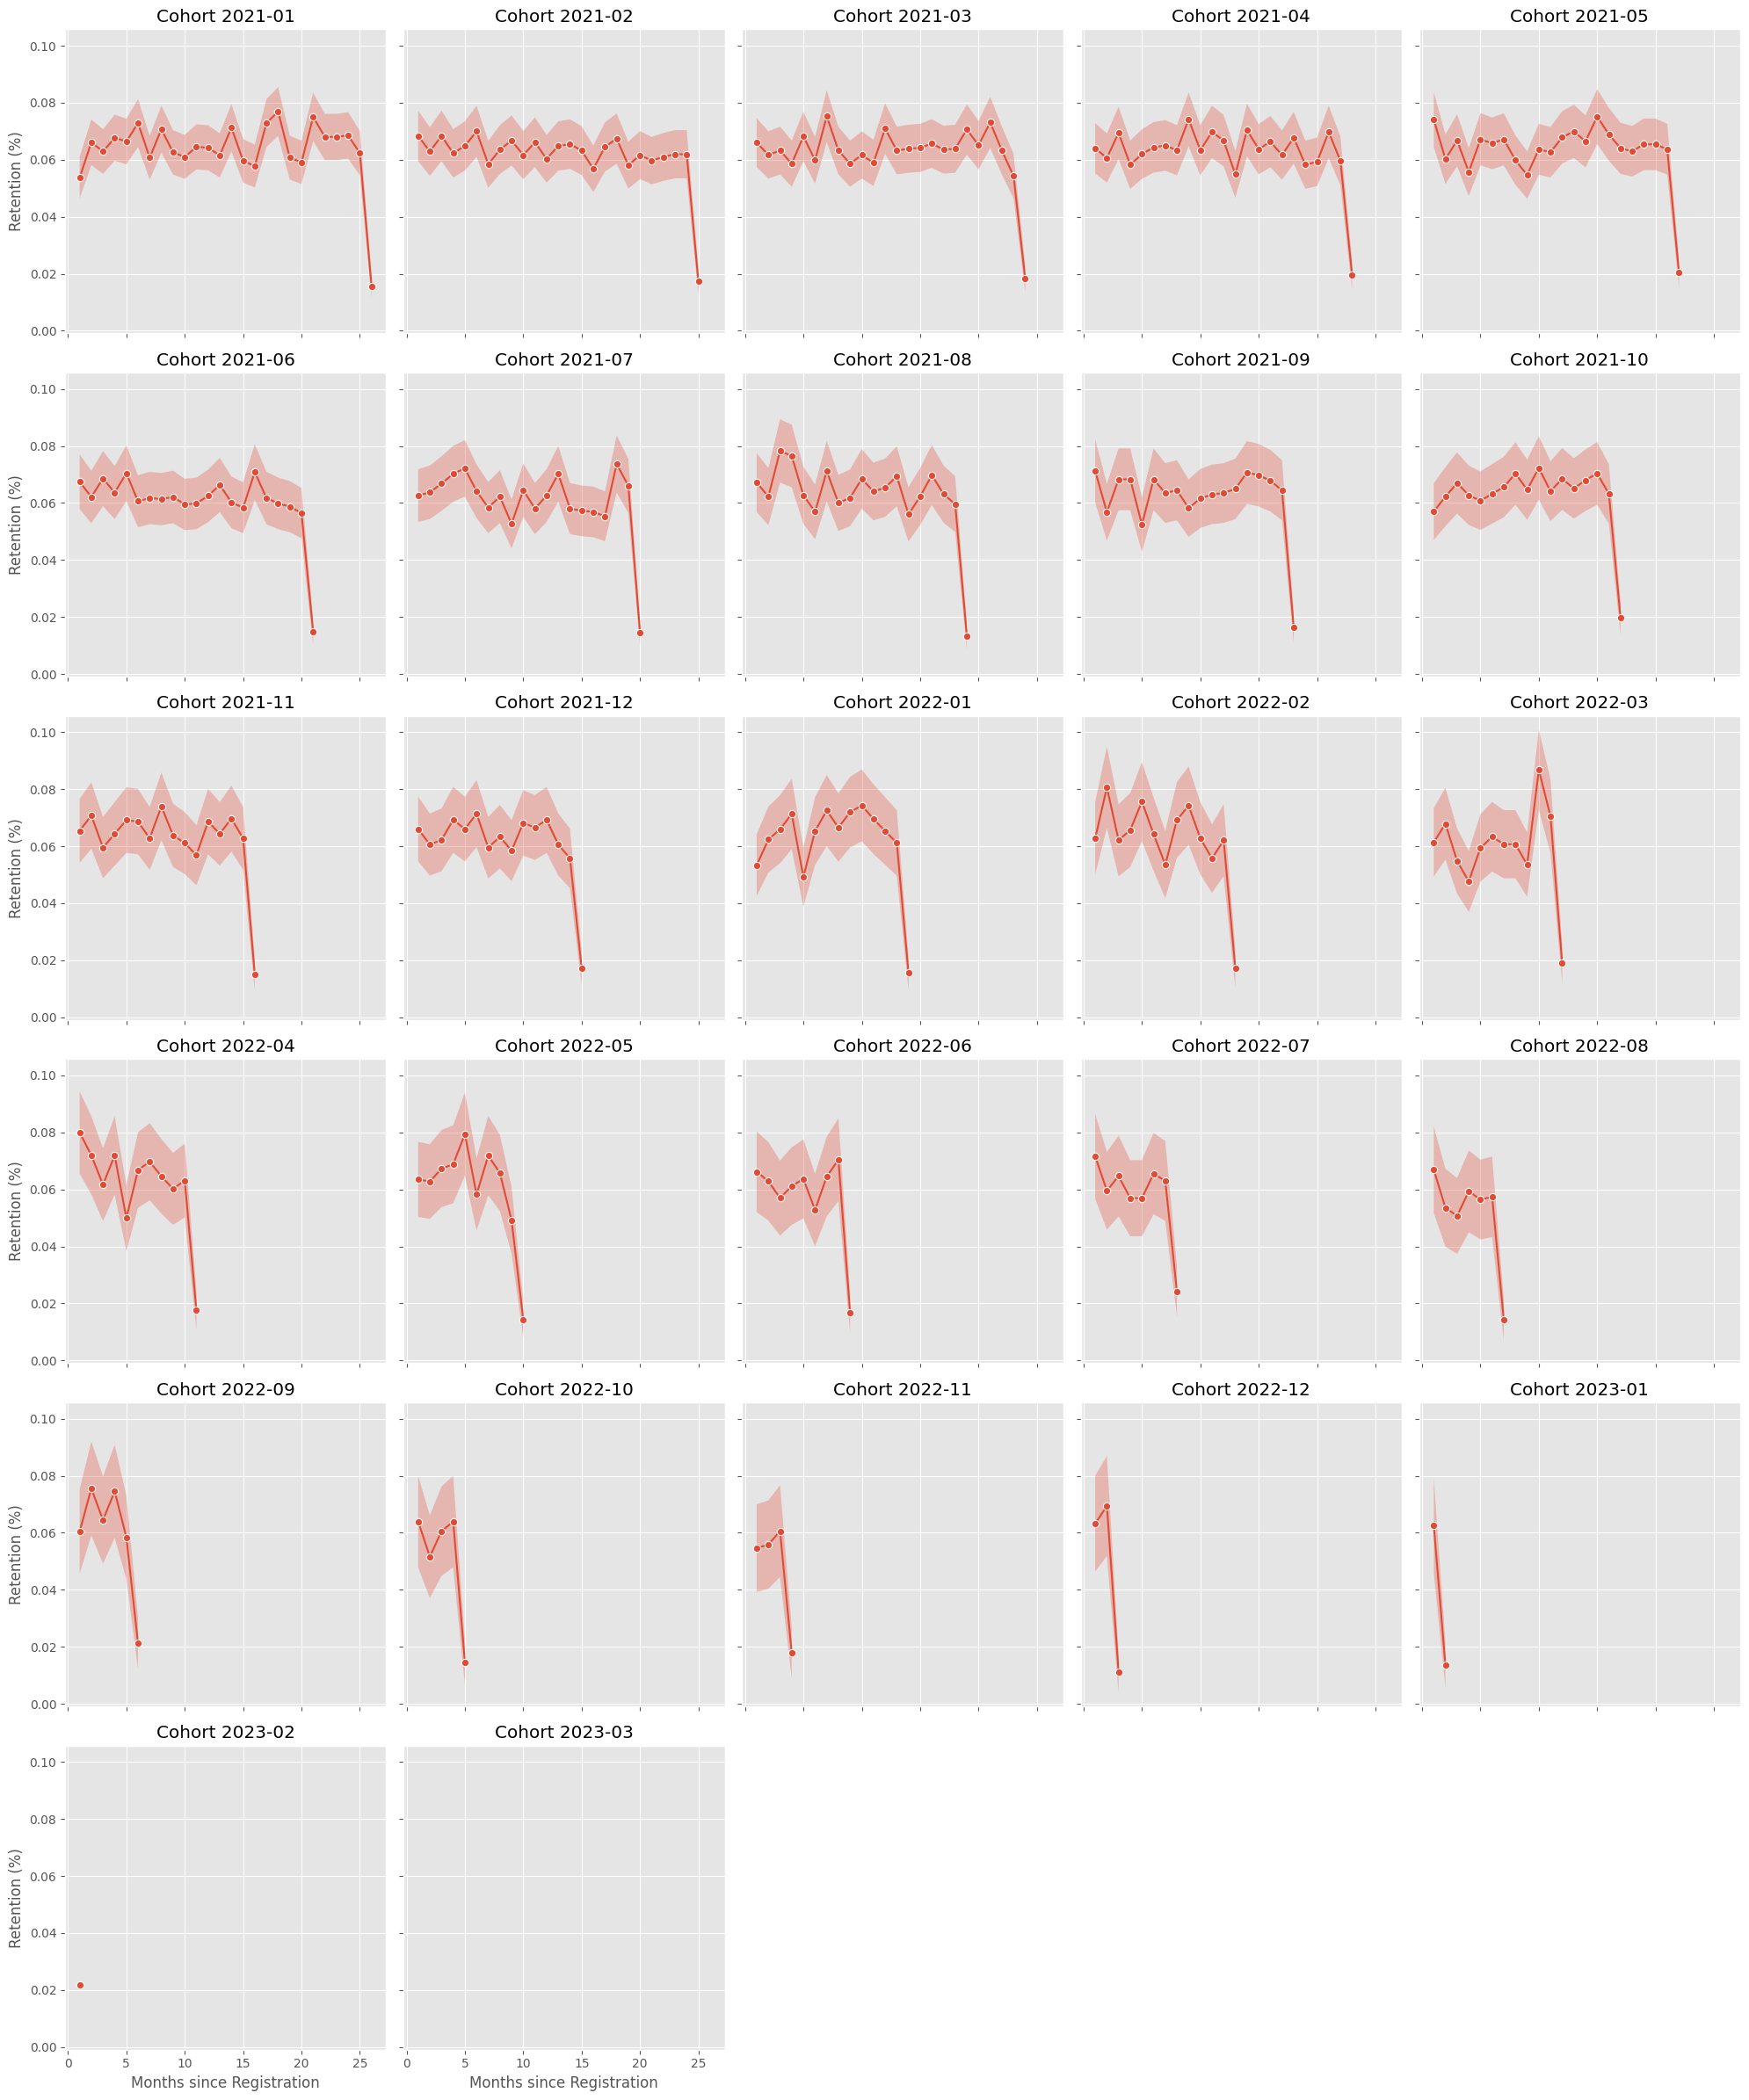

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

"""
строим график как в прошлом задании, но с доверительными интервалами
"""
z_value = 1.96  # Для 95% доверительного интервала

# Повторяем код из прошлой секции
unique_cohorts = cohort_data['cohort'].unique()
cohorts_per_row = 5
n_rows = math.ceil(len(unique_cohorts) / cohorts_per_row)
fig, axes = plt.subplots(n_rows, cohorts_per_row, figsize=(20, 4 * n_rows), sharex=True, sharey=True)
if n_rows == 1:
    axes = [axes]
axes = axes.flatten()


for idx, cohort in enumerate(unique_cohorts):
    cohort_retention = cohort_data[
        (cohort_data['cohort'] == cohort) &
        (cohort_data['retention'] < 1.0)  # Убираем retention = 100%
    ].copy()

    # Расчет доверительных интервалов
    cohort_retention.loc[:, 'ci_lower'] = cohort_retention.apply(
        lambda row: max(0, row['retention'] - z_value * np.sqrt(row['retention'] * (1 - row['retention']) / row['initial_users'])),
        axis=1
    )
    cohort_retention.loc[:, 'ci_upper'] = cohort_retention.apply(
        lambda row: min(1, row['retention'] + z_value * np.sqrt(row['retention'] * (1 - row['retention']) / row['initial_users'])),
        axis=1
    )

    # Построение линии для текущей когорты
    sns.lineplot(
        data=cohort_retention,
        x='month_since_registration',
        y='retention',
        marker='o',
        ax=axes[idx]
    )

    # Добавляем область доверительного интервала
    axes[idx].fill_between(
        cohort_retention['month_since_registration'],
        cohort_retention['ci_lower'],
        cohort_retention['ci_upper'],
        alpha=0.3
    )

    # Настройка текущего сабплота
    axes[idx].set_title(f'Cohort {cohort}')
    axes[idx].set_xlabel('Months since Registration')
    axes[idx].set_ylabel('Retention (%)')
    axes[idx].grid(True)

# Убираем пустые сабплоты, если когорт меньше, чем количество графиков
for ax in axes[len(unique_cohorts):]:
    ax.set_visible(False)

# Настройка общего пространства между графиками
plt.tight_layout()
plt.show()


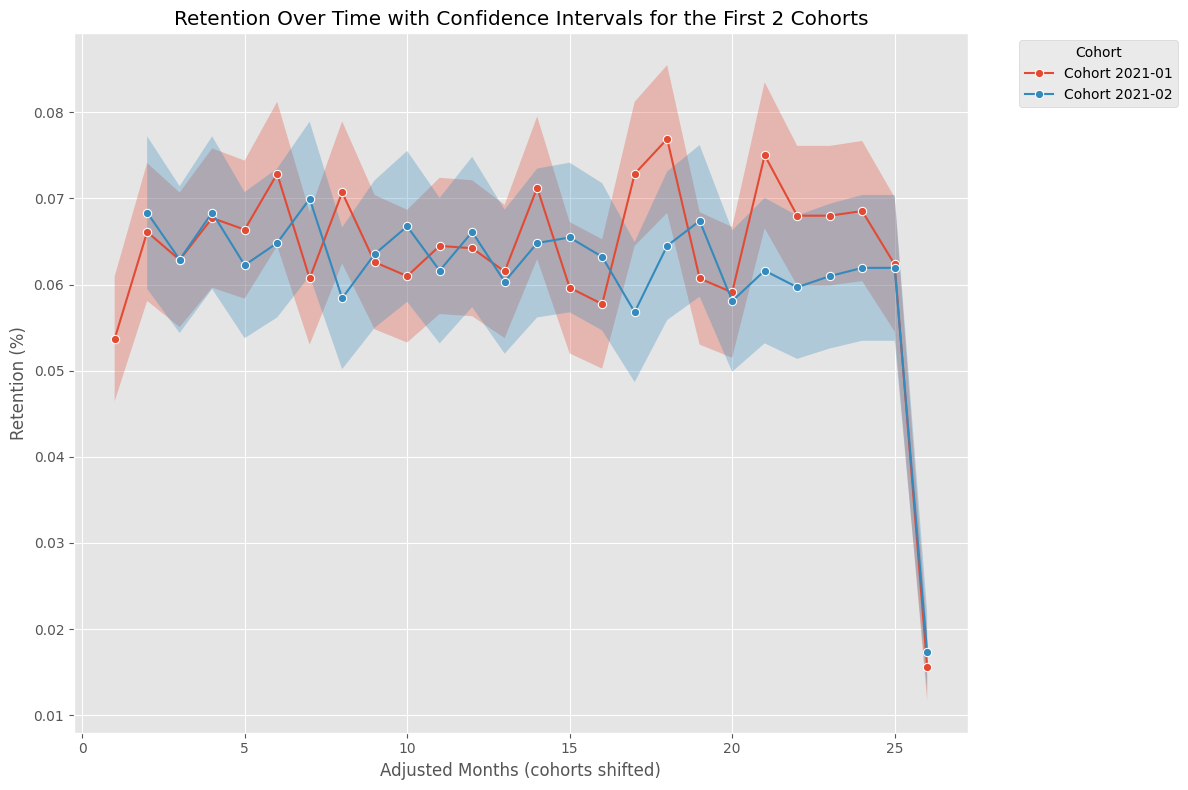

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Устанавливаем z-значение для 95% доверительного интервала
z_value = 1.96

# Определяем количество когорт, которые хотим отобразить
N = 2

# Получаем первые N уникальных когорт
unique_cohorts = cohort_data['cohort'].unique()[:N]

# Создаем фигуру для одного общего графика
plt.figure(figsize=(12, 8))

# Проходим по выбранным когортам и строим их на одном графике
for i, cohort in enumerate(unique_cohorts):
    # Фильтруем данные по текущей когорте
    cohort_retention = cohort_data[
        (cohort_data['cohort'] == cohort) &
        (cohort_data['retention'] < 1.0)  # Убираем retention = 100%
    ].copy()

    # Расчет доверительных интервалов
    cohort_retention['ci_lower'] = cohort_retention.apply(
        lambda row: max(0, row['retention'] - z_value * np.sqrt(row['retention'] * (1 - row['retention']) / row['initial_users'])),
        axis=1
    )
    cohort_retention['ci_upper'] = cohort_retention.apply(
        lambda row: min(1, row['retention'] + z_value * np.sqrt(row['retention'] * (1 - row['retention']) / row['initial_users'])),
        axis=1
    )

    # Добавляем сдвиг по оси X для текущей когорты
    cohort_retention['adjusted_month'] = cohort_retention['month_since_registration'] + i

    # Строим линию удержания для текущей когорты с учётом сдвига
    sns.lineplot(
        data=cohort_retention,
        x='adjusted_month',
        y='retention',
        marker='o',
        label=f'Cohort {cohort}'
    )

    # Добавляем область доверительного интервала для текущей когорты
    plt.fill_between(
        cohort_retention['adjusted_month'],
        cohort_retention['ci_lower'],
        cohort_retention['ci_upper'],
        alpha=0.3
    )

# Настройки графика
plt.title(f'Retention Over Time with Confidence Intervals for the First {N} Cohorts')
plt.xlabel('Adjusted Months (cohorts shifted)')
plt.ylabel('Retention (%)')
plt.grid(True)
plt.legend(title='Cohort', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Отображаем график
plt.show()

Для сравнения кохорт можем вывести N кохорт совмещенных вместе

## 15. Посчитайте средний доход с пользователя (ARPU) в каждом месяце и доверительные интервалы для него (5 баллов)
ARPU = Average Revenue Per User  
1) Постройте график ARPU для каждого месяца      
2) Добавьте на график область доверительного интервала для каждого месяца

In [26]:
df['invoice_month'] = df['invoice_date'].dt.to_period('M')
df['revenue'] = df['quantity'] * df['price']

# Группируем по месяцу и пользователю, чтобы получить выручку по каждому пользователю в каждом месяце
# 2021-01	002g2faqeu	300.08
#         00hzcisefd	365.94
#               ...
#         00kdz3zyqi	5401.53

users_revenue_per_each_month = df.groupby(['invoice_month', 'customer_id'])['revenue'].sum().reset_index()

# Вычисляем среднее revenue / число покупателей в данном месяце
arpu_per_month = users_revenue_per_each_month.groupby('invoice_month')['revenue'].mean()
arpu_per_month.head()

,revenue
invoice_month,
2021-01,2601.622941
2021-02,2646.248935
2021-03,2555.502535
2021-04,2611.107214
2021-05,2621.882739


In [27]:
# Считаем отклонение (s) и число самплов (n) - пользователей
std = users_revenue_per_each_month.groupby('invoice_month')['revenue'].std()
n = users_revenue_per_each_month.groupby('invoice_month')['revenue'].count()

arpu_std_error = std / np.sqrt(n)

confidence_interval = 1.95 * arpu_std_error

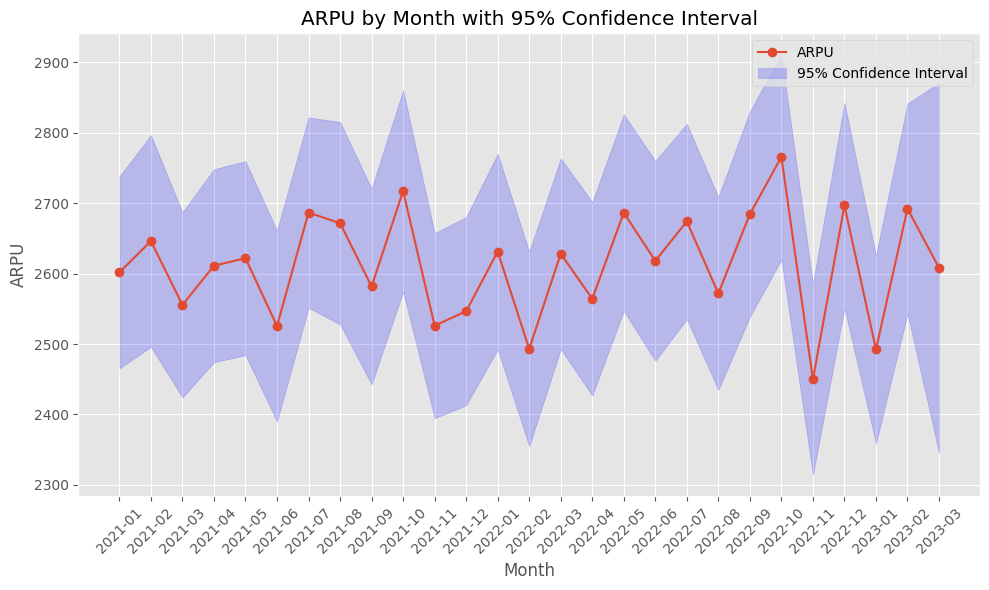

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(arpu_per_month.index.astype(str), arpu_per_month, label='ARPU', marker='o')
plt.fill_between(arpu_per_month.index.astype(str),
                 arpu_per_month - confidence_interval,
                 arpu_per_month + confidence_interval,
                 color='b', alpha=0.2, label='95% Confidence Interval')

plt.xlabel('Month')
plt.ylabel('ARPU')
plt.title('ARPU by Month with 95% Confidence Interval')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()